# Entkopplung von Wirtschaftswachstum und CO₂-Emissionen in Europa

## Historische Analyse der EU-27 und Prognose für Deutschland bis 2030

**Forschungsfrage:** Hat seit 2005 in der Mehrheit der heutigen EU-27-Staaten
eine absolute Entkopplung von Wirtschaftswachstum und territorialen
CO₂-Emissionen stattgefunden?

**These:** Für mehr als 50 % der EU-27-Staaten mit vollständigen Daten gilt
zwischen 2005 und dem letzten gemeinsamen verfügbaren Jahr: Das reale
Gesamt-BIP ist gestiegen, während die territorialen CO₂-Gesamtemissionen
gesunken sind.

**Operationalisierung:**

$$\Delta BIP_i > 0 \quad \land \quad \Delta CO_{2,i} < 0$$

Die primäre Entscheidung vergleicht 2005 mit dem letzten gemeinsamen Jahr. Ein
log-linearer Trend über alle Jahre dient als Robustheitsprüfung. Anschließend
werden transparente Prognose-Baselines für Deutschlands CO₂-Emissionen bis
2030 mit zeitlich geordneter Validierung verglichen.

## 1. Setup und Reproduzierbarkeit

Alle Zufallsprozesse verwenden einen festen Startwert. Rohdaten werden nur
heruntergeladen, wenn die eingefrorene lokale Kopie fehlt. Die Analyse
überschreibt keine Rohdaten; abgeleitete Tabellen und Grafiken landen in
separaten Verzeichnissen.

In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures"
for directory in (RAW_DIR, PROCESSED_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 180,
})

print(f"Python: {sys.version.split()[0]}")
print(f"Projektwurzel: {ROOT}")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\morri\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Python: 3.12.6
Projektwurzel: C:\Users\morri\PycharmProjects\BigDataCo2Emissions


## 2. Datenquellen und Begriffe

Die vom Aufgabensteller bereitgestellte Reihe zu CO₂-Emissionen pro Kopf wird
um zwei OWID-Reihen ergänzt, weil die These **Gesamt-BIP** und
**Gesamtemissionen** vergleicht:

1. CO₂ pro Kopf – bereitgestellter Ausgangsdatensatz
2. territoriale CO₂-Gesamtemissionen
3. reales Gesamt-BIP in konstanten US-Dollar

Die CO₂-Daten basieren auf dem Global Carbon Budget 2025. Erfasst werden
fossile Brennstoffe und industrielle Prozesse. Landnutzungsänderungen sind
ausgeschlossen. Internationale Luftfahrt und Schifffahrt werden keinem
einzelnen Land zugerechnet. „Territorial“ bezeichnet den Ort der Emission und
nicht den Konsumort importierter Güter.

In [2]:
DATASETS = {
    "co-emissions-per-capita": {
        "csv": "https://ourworldindata.org/grapher/co-emissions-per-capita.csv?v=1&csvType=full&useColumnShortNames=true",
        "metadata": "https://ourworldindata.org/grapher/co-emissions-per-capita.metadata.json?v=1&csvType=full&useColumnShortNames=true",
    },
    "annual-co2-emissions-per-country": {
        "csv": "https://ourworldindata.org/grapher/annual-co2-emissions-per-country.csv?v=1&csvType=full&useColumnShortNames=true",
        "metadata": "https://ourworldindata.org/grapher/annual-co2-emissions-per-country.metadata.json?v=1&csvType=full&useColumnShortNames=true",
    },
    "gdp-worldbank-constant-usd": {
        "csv": "https://ourworldindata.org/grapher/gdp-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "metadata": "https://ourworldindata.org/grapher/gdp-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
    },
}

USER_AGENT = "BigDataCo2Emissions university project/1.0"


def fetch_if_missing(url: str, path: Path) -> None:
    # Download once and otherwise use the frozen local copy.
    if path.exists():
        return
    response = requests.get(url, headers={"User-Agent": USER_AGENT}, timeout=120)
    response.raise_for_status()
    path.write_bytes(response.content)


for slug, urls in DATASETS.items():
    fetch_if_missing(urls["csv"], RAW_DIR / f"{slug}.csv")
    fetch_if_missing(urls["metadata"], RAW_DIR / f"{slug}.metadata.json")

per_capita = pd.read_csv(RAW_DIR / "co-emissions-per-capita.csv")
emissions = pd.read_csv(RAW_DIR / "annual-co2-emissions-per-country.csv")
gdp = pd.read_csv(RAW_DIR / "gdp-worldbank-constant-usd.csv")

with (RAW_DIR / "co-emissions-per-capita.metadata.json").open(encoding="utf-8") as file:
    per_capita_metadata = json.load(file)
with (RAW_DIR / "annual-co2-emissions-per-country.metadata.json").open(encoding="utf-8") as file:
    emissions_metadata = json.load(file)
with (RAW_DIR / "gdp-worldbank-constant-usd.metadata.json").open(encoding="utf-8") as file:
    gdp_metadata = json.load(file)

overview = pd.DataFrame({
    "Datensatz": ["CO₂ pro Kopf", "CO₂ gesamt", "Reales BIP"],
    "Zeilen": [len(per_capita), len(emissions), len(gdp)],
    "Entitäten": [per_capita["entity"].nunique(), emissions["entity"].nunique(), gdp["entity"].nunique()],
    "Von": [per_capita["year"].min(), emissions["year"].min(), gdp["year"].min()],
    "Bis": [per_capita["year"].max(), emissions["year"].max(), gdp["year"].max()],
})
display(overview)

print("CO₂-Metadaten:", per_capita_metadata["chart"]["citation"])
print("BIP-Metadaten:", gdp_metadata["chart"]["citation"])

,Datensatz,Zeilen,Entitäten,Von,Bis
0,CO₂ pro Kopf,26509,231,1750,2024
1,CO₂ gesamt,29384,247,1750,2024
2,Reales BIP,12382,226,1960,2025


CO₂-Metadaten: Global Carbon Budget (2025); Population based on various sources (2024)
BIP-Metadaten: National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates (2026)


## 3. Auswahl und Zusammenführung der EU-27

Untersucht werden die heutigen 27 EU-Mitgliedstaaten. Die Auswahl erfolgt über
ISO-3-Codes, damit Länderbezeichnungen aus verschiedenen Quellen nicht zu
fehlerhaften Joins führen. Das Endjahr ist das jüngste Jahr, für das alle 27
Staaten vollständige Werte für CO₂ pro Kopf, Gesamtemissionen und reales BIP
aufweisen.

In [3]:
EU27 = {
    "AUT": "Austria", "BEL": "Belgium", "BGR": "Bulgaria", "HRV": "Croatia",
    "CYP": "Cyprus", "CZE": "Czechia", "DNK": "Denmark", "EST": "Estonia",
    "FIN": "Finland", "FRA": "France", "DEU": "Germany", "GRC": "Greece",
    "HUN": "Hungary", "IRL": "Ireland", "ITA": "Italy", "LVA": "Latvia",
    "LTU": "Lithuania", "LUX": "Luxembourg", "MLT": "Malta", "NLD": "Netherlands",
    "POL": "Poland", "PRT": "Portugal", "ROU": "Romania", "SVK": "Slovakia",
    "SVN": "Slovenia", "ESP": "Spain", "SWE": "Sweden",
}

pc_eu = per_capita.loc[per_capita["code"].isin(EU27)].rename(
    columns={"emissions_total_per_capita": "co2_per_capita_t"}
)
co2_eu = emissions.loc[emissions["code"].isin(EU27)].rename(
    columns={"emissions_total": "co2_total_t"}
)
gdp_eu = gdp.loc[gdp["code"].isin(EU27)].rename(
    columns={"ny_gdp_mktp_kd": "gdp_constant_usd"}
)

panel = (
    co2_eu[["entity", "code", "year", "co2_total_t"]]
    .merge(pc_eu[["code", "year", "co2_per_capita_t"]], on=["code", "year"], how="outer", validate="one_to_one")
    .merge(gdp_eu[["code", "year", "gdp_constant_usd"]], on=["code", "year"], how="outer", validate="one_to_one")
    .sort_values(["code", "year"])
    .reset_index(drop=True)
)

panel["entity"] = panel["code"].map(EU27)
panel["co2_total_mt"] = panel["co2_total_t"] / 1_000_000
panel["gdp_billion_usd"] = panel["gdp_constant_usd"] / 1_000_000_000

required = ["co2_total_t", "co2_per_capita_t", "gdp_constant_usd"]
coverage = (
    panel.loc[panel["year"] >= 2005]
    .assign(complete=lambda x: x[required].notna().all(axis=1))
    .groupby("year")["complete"]
    .sum()
)
common_years = coverage[coverage.eq(len(EU27))].index
START_YEAR = 2005
END_YEAR = int(common_years.max())

analysis_panel = panel.loc[panel["year"].between(START_YEAR, END_YEAR)].copy()
analysis_panel.to_csv(PROCESSED_DIR / "eu27_panel.csv", index=False)

print(f"Analysezeitraum: {START_YEAR}–{END_YEAR}")
print(f"EU-27-Staaten mit vollständigen Endpunkten: {coverage.loc[END_YEAR]} von {len(EU27)}")
display(coverage.tail(10).rename("vollständige Staaten").to_frame())

Analysezeitraum: 2005–2024
EU-27-Staaten mit vollständigen Endpunkten: 27 von 27


,vollständige Staaten
year,
2016,27
2017,27
2018,27
2019,27
2020,27
2021,27
2022,27
2023,27
2024,27


## 4. Datenqualität

Geprüft werden Datentypen, Duplikate, fehlende Werte und auffällige Länderwerte.
Fehlende Werte werden **nicht automatisch imputiert**: Bei nationalen
Zeitreihen könnte eine Imputation echte historische Brüche glätten. Für die
Kernanalyse wird stattdessen ein gemeinsames vollständiges Endjahr gewählt.

,Kennzahl,Wert
0,Zeilen im EU-27-Analysepanel,540
1,Doppelte Land-Jahr-Schlüssel,0
2,Fehlende CO₂-Gesamtwerte,0
3,Fehlende CO₂-pro-Kopf-Werte,0
4,Fehlende BIP-Werte,0


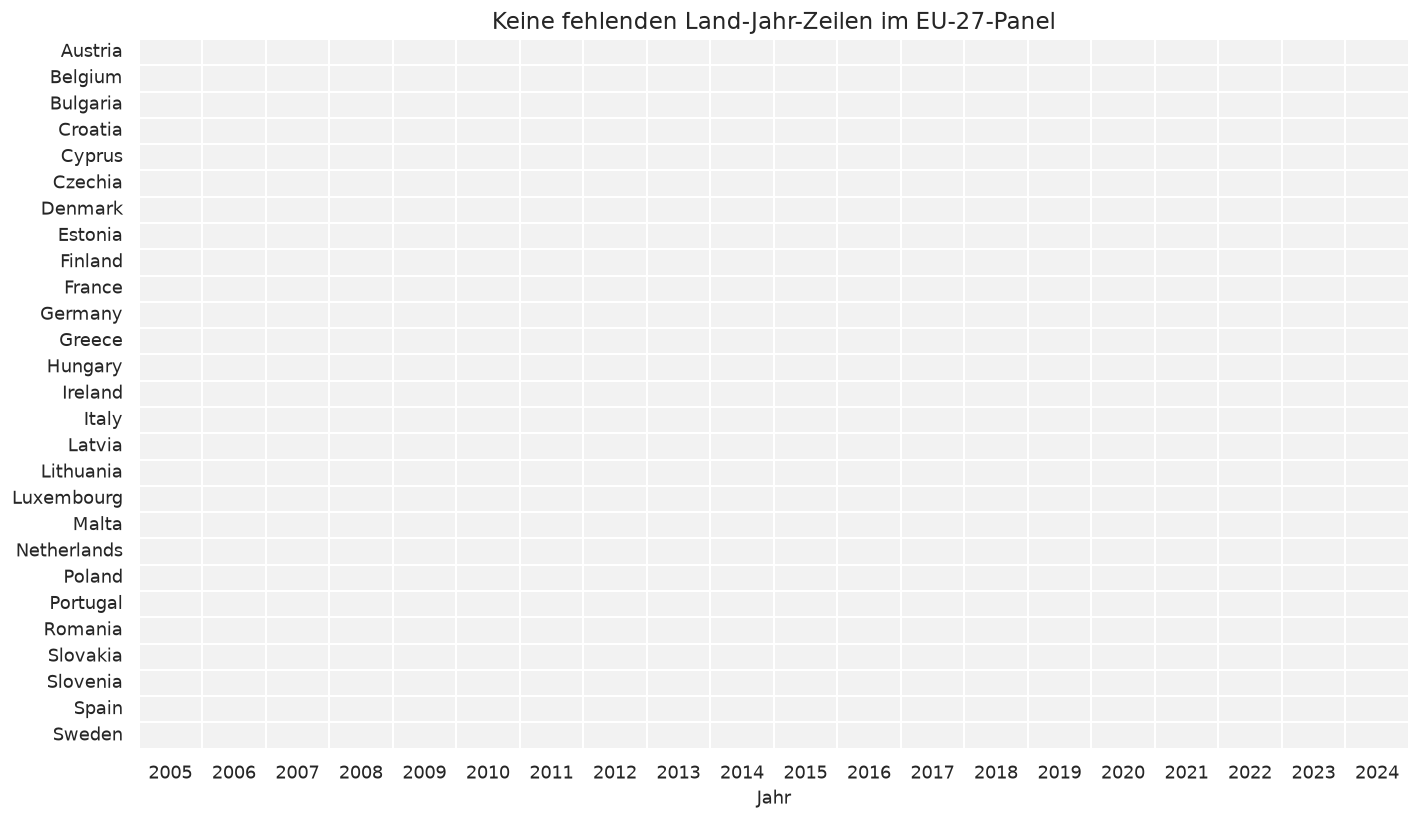

In [4]:
quality = pd.DataFrame({
    "Kennzahl": [
        "Zeilen im EU-27-Analysepanel",
        "Doppelte Land-Jahr-Schlüssel",
        "Fehlende CO₂-Gesamtwerte",
        "Fehlende CO₂-pro-Kopf-Werte",
        "Fehlende BIP-Werte",
    ],
    "Wert": [
        len(analysis_panel),
        analysis_panel.duplicated(["code", "year"]).sum(),
        analysis_panel["co2_total_t"].isna().sum(),
        analysis_panel["co2_per_capita_t"].isna().sum(),
        analysis_panel["gdp_constant_usd"].isna().sum(),
    ],
})
display(quality)

missing_matrix = (
    analysis_panel.set_index(["entity", "year"])[required]
    .isna()
    .any(axis=1)
    .unstack("year")
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(missing_matrix, cmap=["#f2f2f2", "#d62728"], cbar=False, linewidths=0.25, ax=ax)
missing_rows = int(missing_matrix.to_numpy().sum())
ax.set_title(
    "Keine fehlenden Land-Jahr-Zeilen im EU-27-Panel"
    if missing_rows == 0
    else f"Fehlende Land-Jahr-Zeilen im EU-27-Panel: {missing_rows}"
)
ax.set_xlabel("Jahr")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_missing_values.png", bbox_inches="tight")
plt.show()

## 5. Deskriptive Analyse und Visualisierung

Für jedes Land werden BIP und Emissionen relativ zu 2005 indexiert. Dadurch
lassen sich unterschiedlich große Volkswirtschaften auf derselben Skala
vergleichen. Die These selbst verwendet unskalierte prozentuale Veränderungen;
eine Standardisierung wäre hierfür nicht erforderlich und würde die
Interpretierbarkeit verschlechtern.

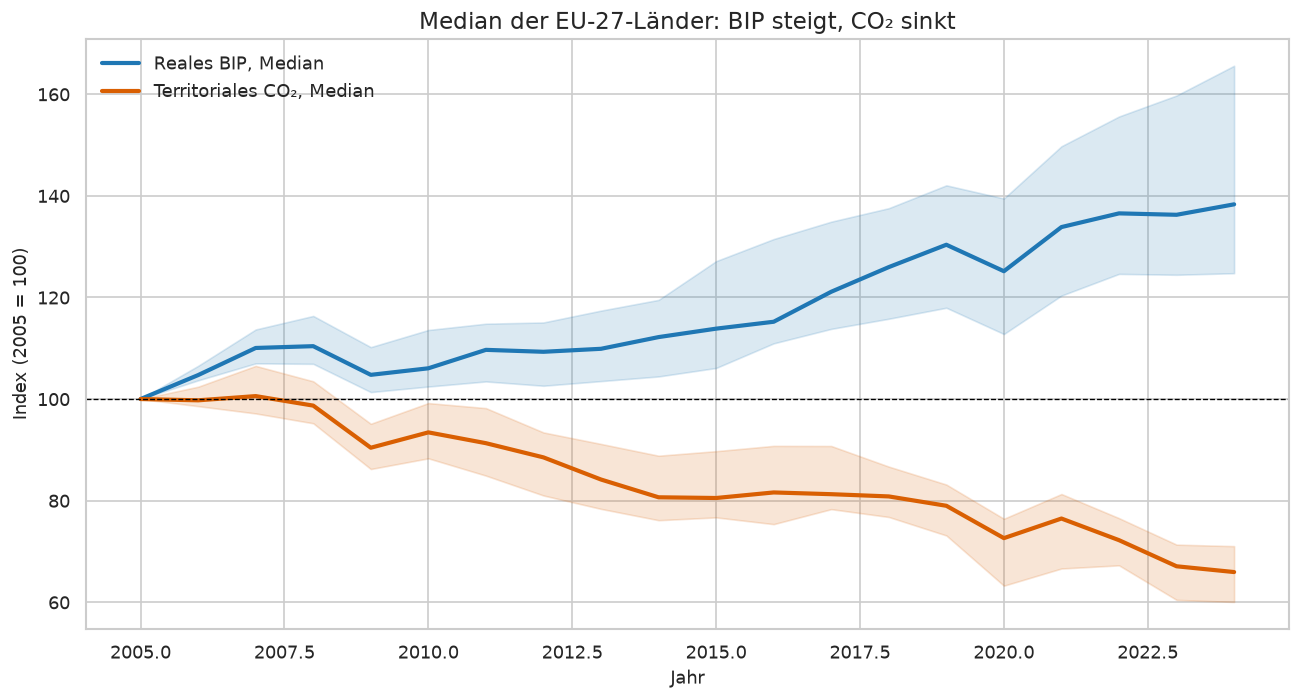

In [5]:
baselines = (
    analysis_panel.loc[analysis_panel["year"].eq(START_YEAR), ["code", "gdp_constant_usd", "co2_total_t"]]
    .set_index("code")
    .rename(columns={"gdp_constant_usd": "gdp_base", "co2_total_t": "co2_base"})
)
indexed = analysis_panel.join(baselines, on="code")
indexed["gdp_index"] = indexed["gdp_constant_usd"] / indexed["gdp_base"] * 100
indexed["co2_index"] = indexed["co2_total_t"] / indexed["co2_base"] * 100

summary_index = indexed.groupby("year").agg(
    gdp_median=("gdp_index", "median"),
    gdp_q25=("gdp_index", lambda s: s.quantile(0.25)),
    gdp_q75=("gdp_index", lambda s: s.quantile(0.75)),
    co2_median=("co2_index", "median"),
    co2_q25=("co2_index", lambda s: s.quantile(0.25)),
    co2_q75=("co2_index", lambda s: s.quantile(0.75)),
)

fig, ax = plt.subplots(figsize=(11, 6))
x = summary_index.index.to_numpy()
ax.plot(x, summary_index["gdp_median"].to_numpy(), color="#1f77b4", linewidth=2.5, label="Reales BIP, Median")
ax.fill_between(x, summary_index["gdp_q25"].to_numpy(), summary_index["gdp_q75"].to_numpy(), color="#1f77b4", alpha=0.16)
ax.plot(x, summary_index["co2_median"].to_numpy(), color="#d95f02", linewidth=2.5, label="Territoriales CO₂, Median")
ax.fill_between(x, summary_index["co2_q25"].to_numpy(), summary_index["co2_q75"].to_numpy(), color="#d95f02", alpha=0.16)
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set(title="Median der EU-27-Länder: BIP steigt, CO₂ sinkt", xlabel="Jahr", ylabel=f"Index ({START_YEAR} = 100)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_eu27_index.png", bbox_inches="tight")
plt.show()

## 6. Prüfung der These

Der Endpunktvergleich beantwortet die These direkt. Zusätzlich werden für
jedes Land jährliche log-lineare Wachstumsraten geschätzt. Absolute Entkopplung
im Robustheitscheck liegt vor, wenn der geschätzte BIP-Trend positiv und der
CO₂-Trend negativ ist.

In [6]:
start = analysis_panel.loc[analysis_panel["year"].eq(START_YEAR)].set_index("code")
end = analysis_panel.loc[analysis_panel["year"].eq(END_YEAR)].set_index("code")

results = pd.DataFrame(index=sorted(EU27))
results["country"] = results.index.map(EU27)
results["gdp_change_pct"] = (end["gdp_constant_usd"] / start["gdp_constant_usd"] - 1) * 100
results["co2_change_pct"] = (end["co2_total_t"] / start["co2_total_t"] - 1) * 100
results["co2_per_capita_change_pct"] = (end["co2_per_capita_t"] / start["co2_per_capita_t"] - 1) * 100
results["absolute_decoupling"] = results["gdp_change_pct"].gt(0) & results["co2_change_pct"].lt(0)


def annual_log_trend(group: pd.DataFrame, column: str) -> float:
    valid = group[["year", column]].dropna()
    valid = valid.loc[valid[column].gt(0)]
    slope = np.polyfit(valid["year"], np.log(valid[column]), 1)[0]
    return (np.exp(slope) - 1) * 100


trends = analysis_panel.groupby("code").apply(
    lambda group: pd.Series({
        "gdp_trend_pct_pa": annual_log_trend(group, "gdp_constant_usd"),
        "co2_trend_pct_pa": annual_log_trend(group, "co2_total_t"),
    }),
    include_groups=False,
)
results = results.join(trends)
results["trend_absolute_decoupling"] = results["gdp_trend_pct_pa"].gt(0) & results["co2_trend_pct_pa"].lt(0)

for column in ["gdp_change_pct", "co2_change_pct", "co2_per_capita_change_pct"]:
    q1, q3 = results[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    results[f"{column}_iqr_outlier"] = ~results[column].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

results = results.reset_index(names="code").sort_values("co2_change_pct")
results.to_csv(PROCESSED_DIR / "decoupling_results.csv", index=False)

decoupled_count = int(results["absolute_decoupling"].sum())
decoupled_share = decoupled_count / len(results)
trend_count = int(results["trend_absolute_decoupling"].sum())
thesis_supported = decoupled_share > 0.5

display(results[[
    "country", "gdp_change_pct", "co2_change_pct", "co2_per_capita_change_pct",
    "absolute_decoupling", "trend_absolute_decoupling"
]].style.format({
    "gdp_change_pct": "{:+.1f}%",
    "co2_change_pct": "{:+.1f}%",
    "co2_per_capita_change_pct": "{:+.1f}%",
}))

display(Markdown(
    f"### Ergebnis der These\n\n"
    f"**{decoupled_count} von {len(results)} Staaten ({decoupled_share:.1%})** erfüllen "
    f"die Endpunktdefinition. Die These wird damit **{'unterstützt' if thesis_supported else 'nicht unterstützt'}**. "
    f"Der Trend-Robustheitscheck klassifiziert {trend_count} von {len(results)} Staaten als absolut entkoppelt."
))

,country,gdp_change_pct,co2_change_pct,co2_per_capita_change_pct,absolute_decoupling,trend_absolute_decoupling
11,Greece,-7.0%,-53.1%,-48.8%,False,False
8,Estonia,+38.3%,-51.4%,-51.6%,True,True
22,Portugal,+19.9%,-49.0%,-48.6%,True,True
9,Finland,+13.5%,-47.8%,-51.3%,True,True
6,Denmark,+28.9%,-45.0%,-50.1%,True,True
17,Luxembourg,+49.7%,-41.7%,-59.7%,True,True
7,Spain,+24.5%,-40.0%,-45.0%,True,True
4,Czechia,+44.2%,-39.8%,-42.4%,True,True
15,Italy,+4.7%,-39.8%,-40.6%,True,True
2,Bulgaria,+62.8%,-37.5%,-28.8%,True,True


### Ergebnis der These

**26 von 27 Staaten (96.3%)** erfüllen die Endpunktdefinition. Die These wird damit **unterstützt**. Der Trend-Robustheitscheck klassifiziert 26 von 27 Staaten als absolut entkoppelt.

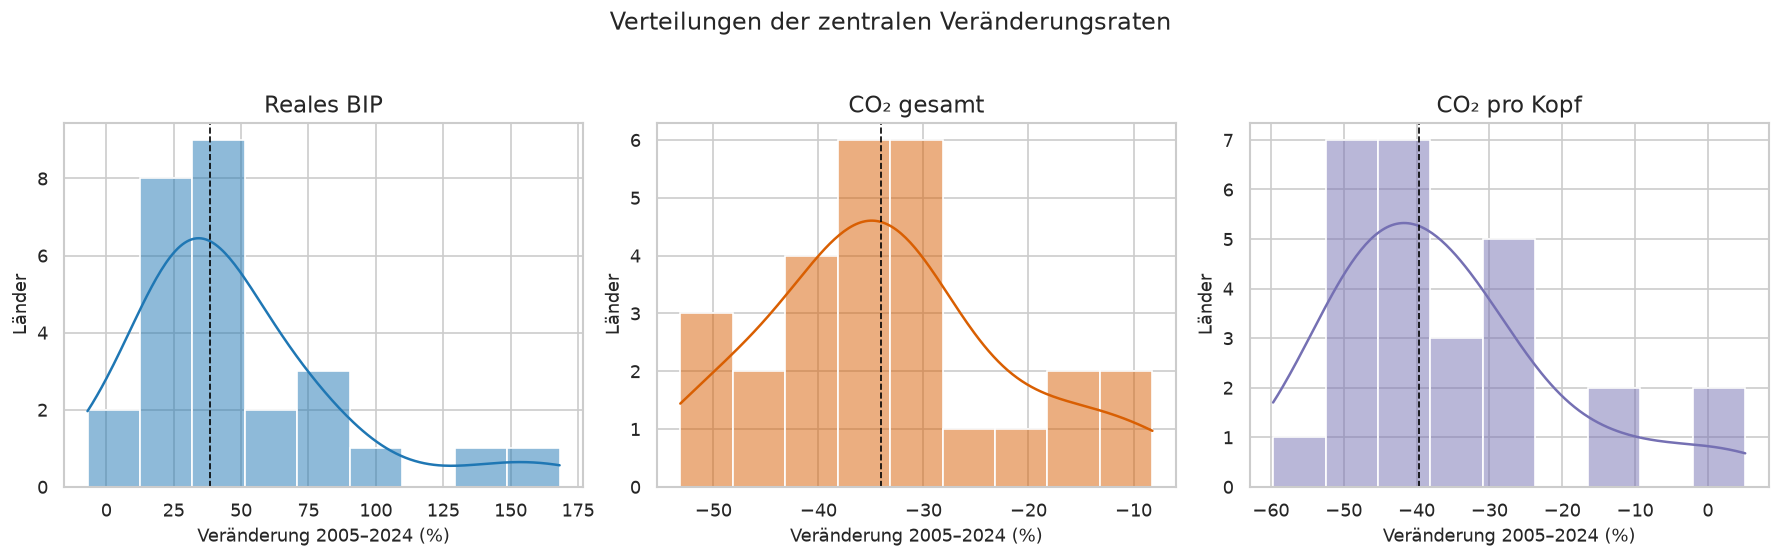

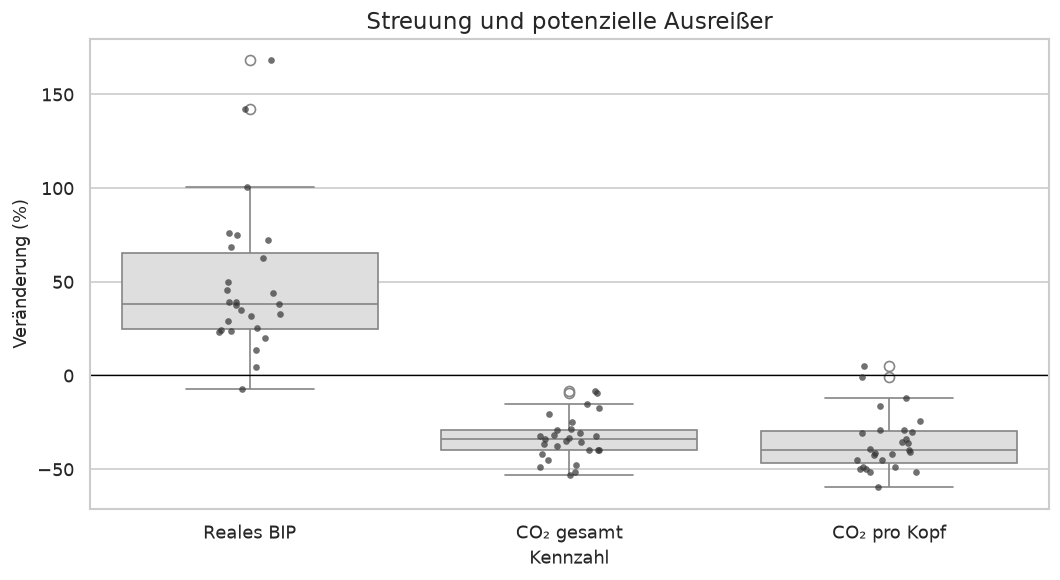

,country,gdp_change_pct,co2_change_pct,co2_per_capita_change_pct
19,Malta,168.162400,-34.758870,-50.027564
14,Ireland,142.432211,-30.823353,-45.300164
18,Latvia,35.067060,-17.269437,-1.008918
16,Lithuania,72.243056,-9.529534,5.125916
3,Cyprus,68.395266,-8.203848,-29.974195


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
hist_columns = [
    ("gdp_change_pct", "Reales BIP", "#1f77b4"),
    ("co2_change_pct", "CO₂ gesamt", "#d95f02"),
    ("co2_per_capita_change_pct", "CO₂ pro Kopf", "#7570b3"),
]
for ax, (column, title, color) in zip(axes, hist_columns):
    sns.histplot(results[column], bins=9, kde=True, color=color, ax=ax)
    ax.axvline(results[column].median(), color="black", linestyle="--", linewidth=1)
    ax.set(title=title, xlabel=f"Veränderung {START_YEAR}–{END_YEAR} (%)", ylabel="Länder")
plt.suptitle("Verteilungen der zentralen Veränderungsraten", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_change_distributions.png", bbox_inches="tight")
plt.show()

long_changes = results.melt(
    id_vars=["country"],
    value_vars=["gdp_change_pct", "co2_change_pct", "co2_per_capita_change_pct"],
    var_name="Kennzahl",
    value_name="Veränderung (%)",
)
labels = {
    "gdp_change_pct": "Reales BIP",
    "co2_change_pct": "CO₂ gesamt",
    "co2_per_capita_change_pct": "CO₂ pro Kopf",
}
long_changes["Kennzahl"] = long_changes["Kennzahl"].map(labels)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=long_changes, x="Kennzahl", y="Veränderung (%)", color="#dedede", ax=ax)
sns.stripplot(data=long_changes, x="Kennzahl", y="Veränderung (%)", color="#333333", size=4, alpha=0.7, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Streuung und potenzielle Ausreißer")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_boxplots.png", bbox_inches="tight")
plt.show()

outlier_columns = [c for c in results if c.endswith("_iqr_outlier")]
display(results.loc[results[outlier_columns].any(axis=1), ["country", *hist_columns[0][:1], "co2_change_pct", "co2_per_capita_change_pct"]])

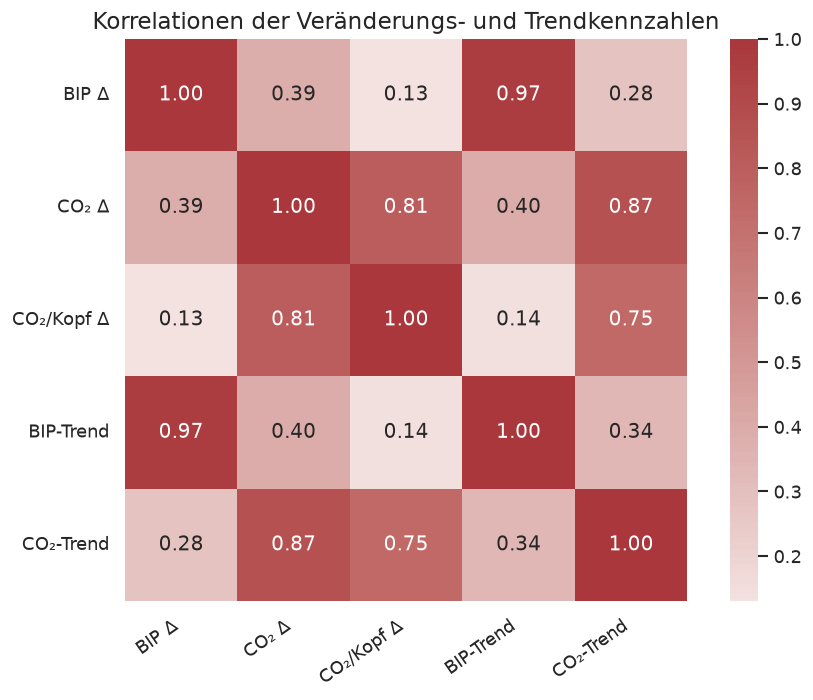

In [8]:
corr_columns = [
    "gdp_change_pct", "co2_change_pct", "co2_per_capita_change_pct",
    "gdp_trend_pct_pa", "co2_trend_pct_pa",
]
corr = results[corr_columns].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Korrelationen der Veränderungs- und Trendkennzahlen")
ax.set_xticklabels(["BIP Δ", "CO₂ Δ", "CO₂/Kopf Δ", "BIP-Trend", "CO₂-Trend"], rotation=35, ha="right")
ax.set_yticklabels(["BIP Δ", "CO₂ Δ", "CO₂/Kopf Δ", "BIP-Trend", "CO₂-Trend"], rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_correlation_heatmap.png", bbox_inches="tight")
plt.show()

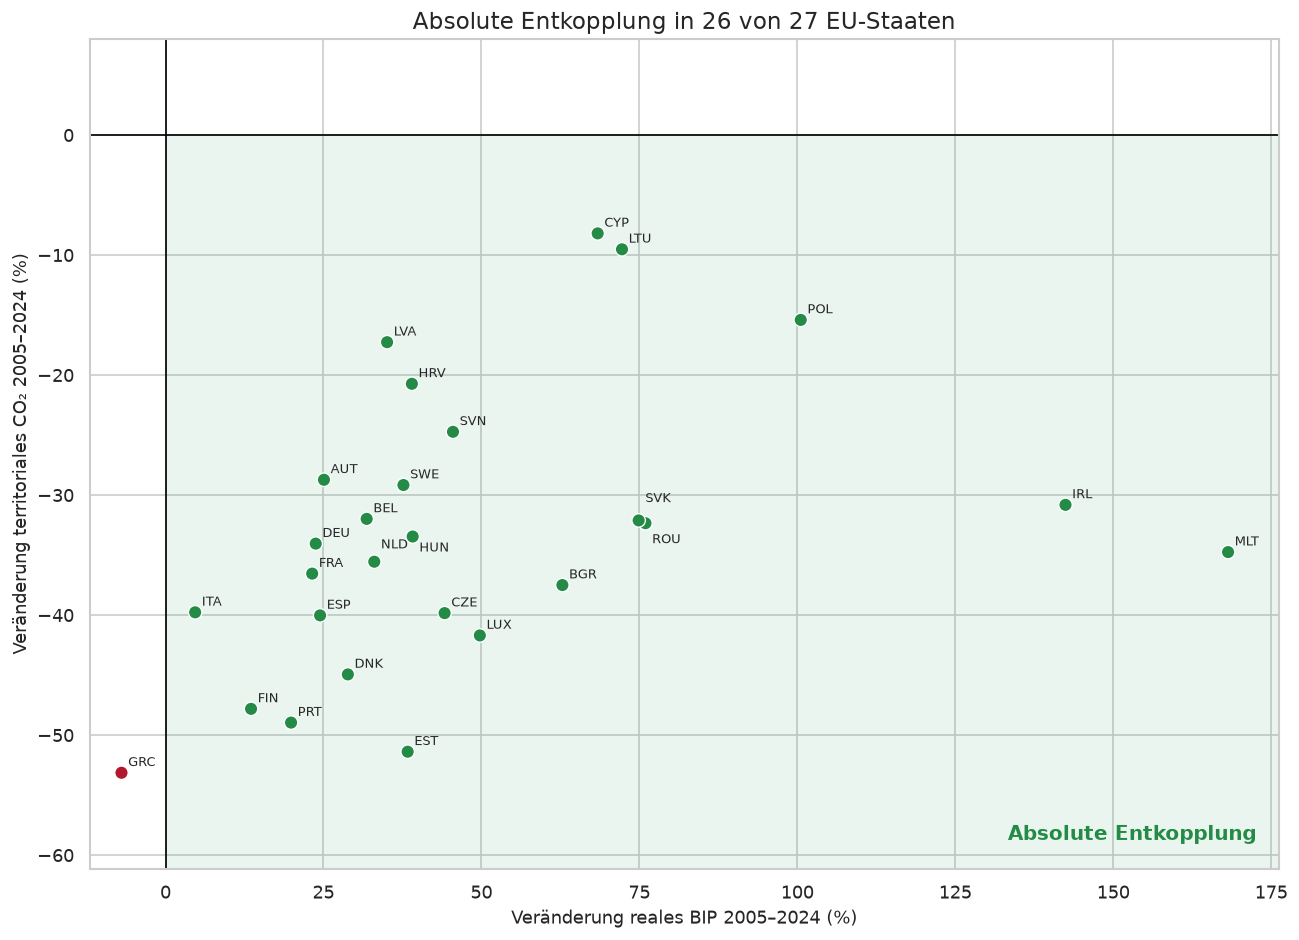

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))

x_min = min(-5, results["gdp_change_pct"].min() - 5)
x_max = results["gdp_change_pct"].max() + 8
y_min = results["co2_change_pct"].min() - 8
y_max = max(8, results["co2_change_pct"].max() + 8)
ax.axvspan(0, x_max, ymin=0, ymax=(0 - y_min) / (y_max - y_min), color="#2ca25f", alpha=0.10)

palette = results["absolute_decoupling"].map({True: "#238b45", False: "#b2182b"})
ax.scatter(results["gdp_change_pct"], results["co2_change_pct"], c=palette, s=65, edgecolor="white", linewidth=0.8)
label_offsets = {"SVK": (4, 11), "ROU": (4, -12), "NLD": (4, 8), "HUN": (4, -9)}
for row in results.itertuples():
    ax.annotate(
        row.code,
        (row.gdp_change_pct, row.co2_change_pct),
        xytext=label_offsets.get(row.code, (4, 4)),
        textcoords="offset points",
        fontsize=8,
    )

ax.axvline(0, color="black", linewidth=1)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set(
    title=f"Absolute Entkopplung in {decoupled_count} von {len(results)} EU-Staaten",
    xlabel=f"Veränderung reales BIP {START_YEAR}–{END_YEAR} (%)",
    ylabel=f"Veränderung territoriales CO₂ {START_YEAR}–{END_YEAR} (%)",
)
ax.text(x_max * 0.98, y_min + 2, "Absolute Entkopplung", ha="right", va="bottom", color="#238b45", weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_decoupling_quadrant.png", bbox_inches="tight")
plt.show()

## 7. Prognose der deutschen CO₂-Emissionen bis 2030

Die deutsche Reihe beginnt 1990, um genügend Beobachtungen und den seit der
Wiedervereinigung relevanten Strukturwandel abzudecken. Fünf transparente
Baselines werden verglichen:

- letzter beobachteter Wert (naiv),
- Drift seit 1990,
- linearer Trend seit 1990,
- linearer Trend der letzten 20 Jahre,
- robuster Huber-Trend der letzten 20 Jahre.

Die Validierung ist zeitlich geordnet. Für mehrere Ursprungsjahre werden jeweils
die folgenden sechs Jahre prognostiziert. Erst nach diesem Out-of-Sample-
Vergleich wird das Modell mit dem niedrigsten RMSE auf allen verfügbaren Daten
neu geschätzt. Das vermeidet eine zufällige Train-Test-Aufteilung und damit
Zukunftsinformationen im Training.

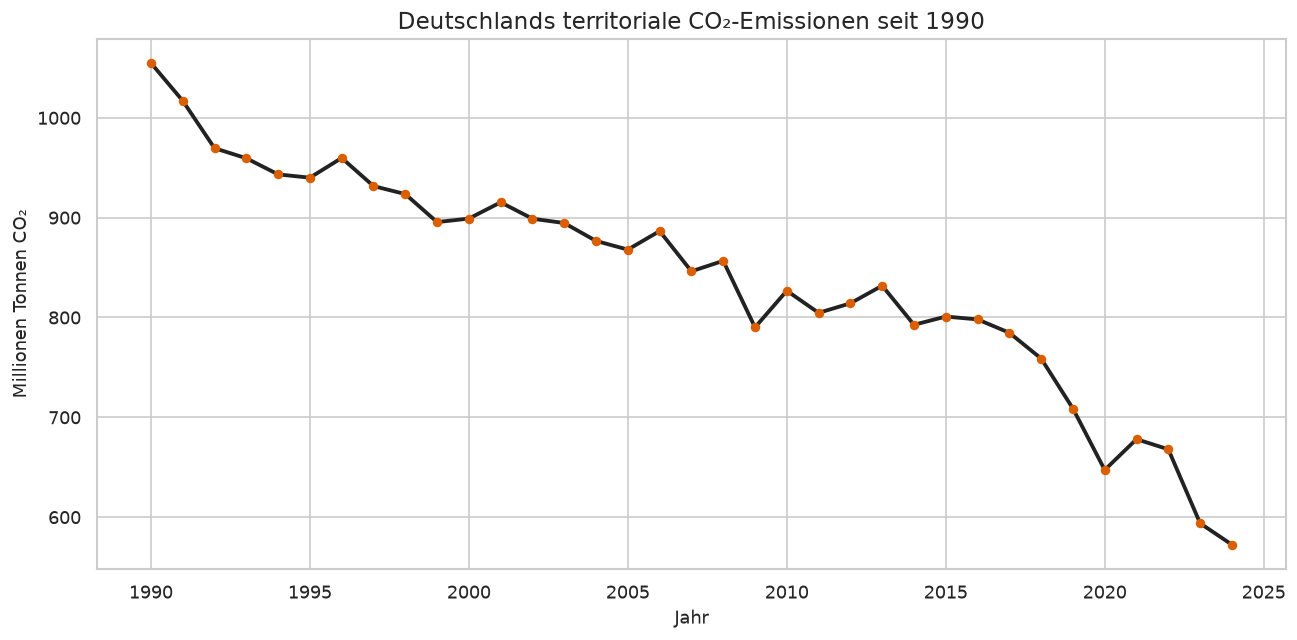

In [10]:
germany = (
    emissions.loc[(emissions["code"].eq("DEU")) & emissions["year"].between(1990, END_YEAR), ["year", "emissions_total"]]
    .rename(columns={"emissions_total": "co2_total_t"})
    .dropna()
    .sort_values("year")
)
germany["co2_total_mt"] = germany["co2_total_t"] / 1_000_000

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(germany["year"], germany["co2_total_mt"], color="#222222", linewidth=2.3)
ax.scatter(germany["year"], germany["co2_total_mt"], color="#d95f02", s=22, zorder=3)
ax.set(title="Deutschlands territoriale CO₂-Emissionen seit 1990", xlabel="Jahr", ylabel="Millionen Tonnen CO₂")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_germany_historical.png", bbox_inches="tight")
plt.show()

,MAE_Mt,RMSE_Mt,Bias_Mt,Prognosen
model,,,,
Drift,45.6,56.6,+12.1,60.000000
Linear 1990+,44.6,57.5,+19.3,60.000000
Huber letzte 20 J.,44.8,58.8,+23.4,60.000000
Linear letzte 20 J.,45.4,59.2,+22.2,60.000000
Naiv,57.2,77.6,+50.4,60.000000


Ausgewähltes Modell: Drift


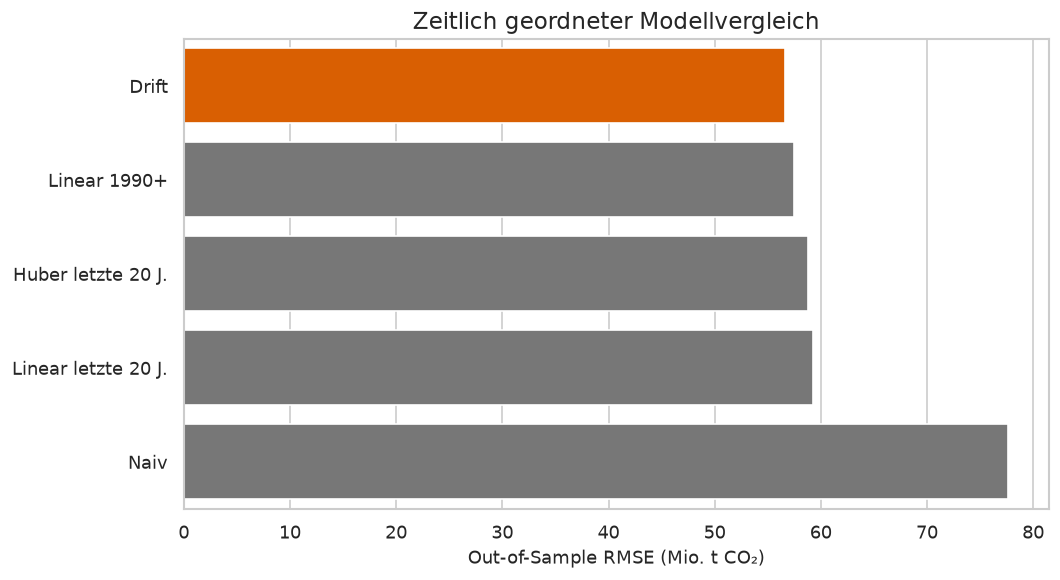

In [11]:
MODELS = ["Naiv", "Drift", "Linear 1990+", "Linear letzte 20 J.", "Huber letzte 20 J."]


def forecast_model(model_name: str, train: pd.DataFrame, future_years: np.ndarray) -> np.ndarray:
    years = train["year"].to_numpy(dtype=float)
    values = train["co2_total_mt"].to_numpy(dtype=float)
    future_years = np.asarray(future_years, dtype=float)

    if model_name == "Naiv":
        return np.repeat(values[-1], len(future_years))
    if model_name == "Drift":
        slope = (values[-1] - values[0]) / (years[-1] - years[0])
        return values[-1] + slope * (future_years - years[-1])

    subset = train if model_name == "Linear 1990+" else train.tail(20)
    x0 = subset["year"].mean()
    x_train = (subset[["year"]].to_numpy() - x0)
    x_future = future_years.reshape(-1, 1) - x0
    if model_name == "Huber letzte 20 J.":
        model = HuberRegressor(epsilon=1.35, alpha=0.0, max_iter=2000)
    else:
        model = LinearRegression()
    model.fit(x_train, subset["co2_total_mt"])
    # Nur die geschätzte Steigung wird fortgeschrieben. Die Prognose startet
    # am letzten beobachteten Wert und erzeugt daher keinen künstlichen Sprung
    # zwischen Historie und Prognose.
    slope = float(model.coef_[0])
    return values[-1] + slope * (future_years - years[-1])


HORIZON = 6
validation_rows = []
for origin in range(2009, END_YEAR - HORIZON + 1):
    train = germany.loc[germany["year"].le(origin)]
    test = germany.loc[germany["year"].between(origin + 1, origin + HORIZON)]
    if len(test) != HORIZON:
        continue
    for model_name in MODELS:
        predictions = forecast_model(model_name, train, test["year"].to_numpy())
        for horizon, (_, actual), predicted in zip(
            range(1, HORIZON + 1), test[["year", "co2_total_mt"]].iterrows(), predictions
        ):
            validation_rows.append({
                "origin": origin,
                "horizon": horizon,
                "model": model_name,
                "actual_mt": actual["co2_total_mt"],
                "predicted_mt": predicted,
                "error_mt": actual["co2_total_mt"] - predicted,
            })

validation = pd.DataFrame(validation_rows)
model_comparison = (
    validation.groupby("model")
    .apply(lambda group: pd.Series({
        "MAE_Mt": mean_absolute_error(group["actual_mt"], group["predicted_mt"]),
        "RMSE_Mt": mean_squared_error(group["actual_mt"], group["predicted_mt"]) ** 0.5,
        "Bias_Mt": group["predicted_mt"].sub(group["actual_mt"]).mean(),
        "Prognosen": len(group),
    }), include_groups=False)
    .sort_values("RMSE_Mt")
)
BEST_MODEL = model_comparison.index[0]
model_comparison.to_csv(PROCESSED_DIR / "forecast_model_comparison.csv")
display(model_comparison.style.format({"MAE_Mt": "{:.1f}", "RMSE_Mt": "{:.1f}", "Bias_Mt": "{:+.1f}"}))
print(f"Ausgewähltes Modell: {BEST_MODEL}")

fig, ax = plt.subplots(figsize=(9, 5))
ordered = model_comparison.sort_values("RMSE_Mt", ascending=True)
sns.barplot(x=ordered["RMSE_Mt"], y=ordered.index, color="#777777", ax=ax)
ax.patches[0].set_facecolor("#d95f02")
ax.set(title="Zeitlich geordneter Modellvergleich", xlabel="Out-of-Sample RMSE (Mio. t CO₂)", ylabel="")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_model_comparison.png", bbox_inches="tight")
plt.show()

,year,forecast_mt,lower_80_mt,upper_80_mt,lower_95_mt,upper_95_mt
0,2025,558.1,527.7,588.9,520.8,603.8
1,2026,543.9,484.6,587.2,461.3,593.0
2,2027,529.7,465.3,571.7,433.1,589.7
3,2028,515.6,444.5,564.9,414.3,601.0
4,2029,501.4,397.6,556.3,391.3,569.3
5,2030,487.2,363.4,543.0,358.1,572.0


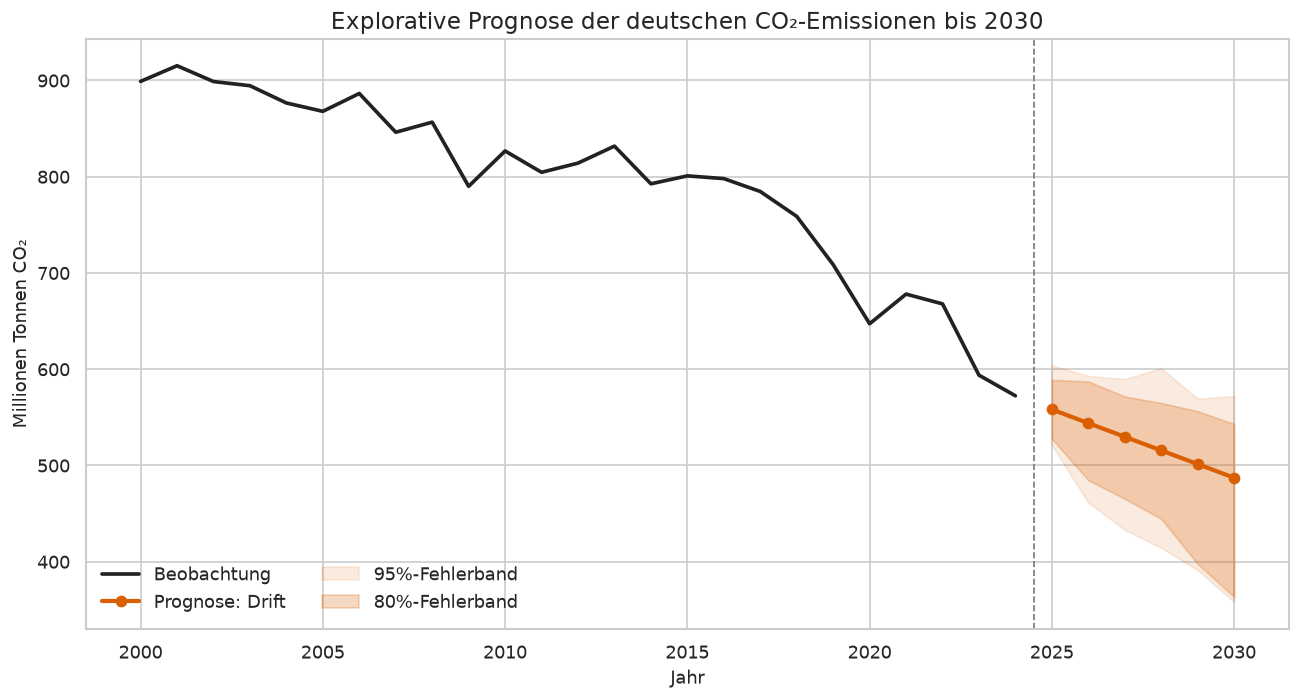

In [12]:
future_years = np.arange(END_YEAR + 1, 2031)
point_forecast = forecast_model(BEST_MODEL, germany, future_years)

selected_errors = validation.loc[validation["model"].eq(BEST_MODEL)]
interval_rows = []
for horizon, year, prediction in zip(range(1, len(future_years) + 1), future_years, point_forecast):
    errors = selected_errors.loc[selected_errors["horizon"].eq(horizon), "error_mt"]
    interval_rows.append({
        "year": int(year),
        "forecast_mt": max(0.0, float(prediction)),
        "lower_80_mt": max(0.0, float(prediction + errors.quantile(0.10))),
        "upper_80_mt": max(0.0, float(prediction + errors.quantile(0.90))),
        "lower_95_mt": max(0.0, float(prediction + errors.quantile(0.025))),
        "upper_95_mt": max(0.0, float(prediction + errors.quantile(0.975))),
    })

forecast = pd.DataFrame(interval_rows)
forecast.to_csv(PROCESSED_DIR / "germany_forecast_2030.csv", index=False)
display(forecast.style.format({column: "{:.1f}" for column in forecast.columns if column != "year"}))

fig, ax = plt.subplots(figsize=(11, 6))
history_window = germany.loc[germany["year"].ge(2000)]
ax.plot(history_window["year"], history_window["co2_total_mt"], color="#222222", linewidth=2.2, label="Beobachtung")
ax.plot(forecast["year"], forecast["forecast_mt"], color="#d95f02", linewidth=2.5, marker="o", label=f"Prognose: {BEST_MODEL}")
ax.fill_between(forecast["year"], forecast["lower_95_mt"], forecast["upper_95_mt"], color="#d95f02", alpha=0.12, label="95%-Fehlerband")
ax.fill_between(forecast["year"], forecast["lower_80_mt"], forecast["upper_80_mt"], color="#d95f02", alpha=0.24, label="80%-Fehlerband")
ax.axvline(END_YEAR + 0.5, color="#777777", linestyle="--", linewidth=1)
ax.set(title="Explorative Prognose der deutschen CO₂-Emissionen bis 2030", xlabel="Jahr", ylabel="Millionen Tonnen CO₂")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_germany_forecast.png", bbox_inches="tight")
plt.show()

## 8. Ergebnis, Interpretation und Grenzen

Die folgende Zusammenfassung wird direkt aus den berechneten Ergebnissen
erzeugt. Dadurch können sich Zahlen bei einer bewussten Aktualisierung der
Rohdaten ändern, ohne dass Text und Grafiken auseinanderlaufen.

In [13]:
deu_result = results.loc[results["code"].eq("DEU")].iloc[0]
forecast_2030 = forecast.loc[forecast["year"].eq(2030)].iloc[0]

analysis_summary = {
    "start_year": START_YEAR,
    "end_year": END_YEAR,
    "country_count": len(results),
    "decoupled_count": decoupled_count,
    "decoupled_share": decoupled_share,
    "trend_decoupled_count": trend_count,
    "thesis_supported": bool(thesis_supported),
    "germany_gdp_change_pct": float(deu_result["gdp_change_pct"]),
    "germany_co2_change_pct": float(deu_result["co2_change_pct"]),
    "best_forecast_model": BEST_MODEL,
    "forecast_2030_mt": float(forecast_2030["forecast_mt"]),
    "forecast_2030_lower_80_mt": float(forecast_2030["lower_80_mt"]),
    "forecast_2030_upper_80_mt": float(forecast_2030["upper_80_mt"]),
    "forecast_2030_lower_95_mt": float(forecast_2030["lower_95_mt"]),
    "forecast_2030_upper_95_mt": float(forecast_2030["upper_95_mt"]),
    "forecast_rmse_mt": float(model_comparison.loc[BEST_MODEL, "RMSE_Mt"]),
}
(PROCESSED_DIR / "analysis_summary.json").write_text(
    json.dumps(analysis_summary, ensure_ascii=False, indent=2), encoding="utf-8"
)

display(Markdown(f'''
### Fazit

- **These:** {decoupled_count} von {len(results)} EU-27-Staaten ({decoupled_share:.1%}) erfüllen von {START_YEAR} bis {END_YEAR} die Endpunktdefinition. Die These wird **{'unterstützt' if thesis_supported else 'nicht unterstützt'}**.
- **Robustheit:** Bei Betrachtung der Trends über den gesamten Zeitraum erfüllen {trend_count} Staaten die strengere Trendbedingung.
- **Deutschland:** Das reale BIP veränderte sich um {deu_result['gdp_change_pct']:+.1f} %, die territorialen CO₂-Emissionen um {deu_result['co2_change_pct']:+.1f} %.
- **Prognose:** Das anhand der zeitlich geordneten Validierung ausgewählte Modell „{BEST_MODEL}“ prognostiziert für 2030 rund **{forecast_2030['forecast_mt']:.0f} Mio. t CO₂**. Das empirische 80%-Fehlerband reicht von {forecast_2030['lower_80_mt']:.0f} bis {forecast_2030['upper_80_mt']:.0f} Mio. t.

### Einschränkungen

1. Der Endpunktvergleich beweist keine Kausalität. Strukturwandel, Energiepreise, Politik und Handel werden nicht separat identifiziert.
2. Territoriale Emissionen können durch die Verlagerung emissionsintensiver Produktion sinken; konsumbezogene Emissionen könnten ein anderes Bild zeigen.
3. Jährliche deutsche Daten ergeben nur eine kleine Stichprobe. Das Fehlerband basiert auf historischen Prognosefehlern und ist keine Garantie.
4. Die Prognose ist eine statistische Fortschreibung historischer Muster, kein politisches oder energiewirtschaftliches Szenario.
5. „Big Data“ beschreibt hier die globale Rohdatensammlung, nicht eine technisch verteilte Datenverarbeitung nach Volume, Velocity und Variety.
'''))


### Fazit

- **These:** 26 von 27 EU-27-Staaten (96.3%) erfüllen von 2005 bis 2024 die Endpunktdefinition. Die These wird **unterstützt**.
- **Robustheit:** Bei Betrachtung der Trends über den gesamten Zeitraum erfüllen 26 Staaten die strengere Trendbedingung.
- **Deutschland:** Das reale BIP veränderte sich um +23.8 %, die territorialen CO₂-Emissionen um -34.1 %.
- **Prognose:** Das anhand der zeitlich geordneten Validierung ausgewählte Modell „Drift“ prognostiziert für 2030 rund **487 Mio. t CO₂**. Das empirische 80%-Fehlerband reicht von 363 bis 543 Mio. t.

### Einschränkungen

1. Der Endpunktvergleich beweist keine Kausalität. Strukturwandel, Energiepreise, Politik und Handel werden nicht separat identifiziert.
2. Territoriale Emissionen können durch die Verlagerung emissionsintensiver Produktion sinken; konsumbezogene Emissionen könnten ein anderes Bild zeigen.
3. Jährliche deutsche Daten ergeben nur eine kleine Stichprobe. Das Fehlerband basiert auf historischen Prognosefehlern und ist keine Garantie.
4. Die Prognose ist eine statistische Fortschreibung historischer Muster, kein politisches oder energiewirtschaftliches Szenario.
5. „Big Data“ beschreibt hier die globale Rohdatensammlung, nicht eine technisch verteilte Datenverarbeitung nach Volume, Velocity und Variety.


## 9. Quellen und KI-Nutzung

**Daten:**

- Global Carbon Budget (2025), aufbereitet von Our World in Data:  
  https://ourworldindata.org/grapher/annual-co2-emissions-per-country
- Global Carbon Budget (2025) und OWID-Bevölkerungsdaten:  
  https://ourworldindata.org/grapher/co-emissions-per-capita
- World Development Indicators, aufbereitet von Our World in Data:  
  https://ourworldindata.org/grapher/gdp-worldbank-constant-usd
- Methodischer Kontext:  
  https://ourworldindata.org/co2-and-greenhouse-gas-emissions

Zu jeder lokalen CSV-Datei liegt die vollständige OWID-Metadaten-JSON vor. Das
Download-Manifest dokumentiert Abrufdatum und Prüfsumme.

**KI-Nutzung:** Generative KI unterstützte Projektstruktur, Codeentwurf,
Methodenvergleich und Präsentationsaufbau. KI-Ausgaben wurden nicht als Quelle
verwendet. Definitionen wurden mit den OWID-Metadaten abgeglichen, alle Zahlen
werden im Notebook reproduziert und die Modellwahl erfolgt anhand gemessener
Out-of-Sample-Fehler. Details stehen in `KI_NUTZUNG.md`.